In [21]:
!uv pip install scikit-learn scikit-image numpy pandas matplotlib opencv-python

Using Python 3.12.3 environment at: venv
Checked 6 packages in 6ms


In [ ]:
import torch
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

In [3]:
# Load the model
  
# Provide explicit path to BPE file  
model = build_sam3_image_model(  
    bpe_path="./sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"  
)  
processor = Sam3Processor(model)

In [6]:
# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

In [34]:
# Load an image
image = Image.open("./img2.jpg")
# image = Image.open("./sam3/assets/images/test_image.jpg")
inference_state = processor.set_image(image)

found 2 object(s)


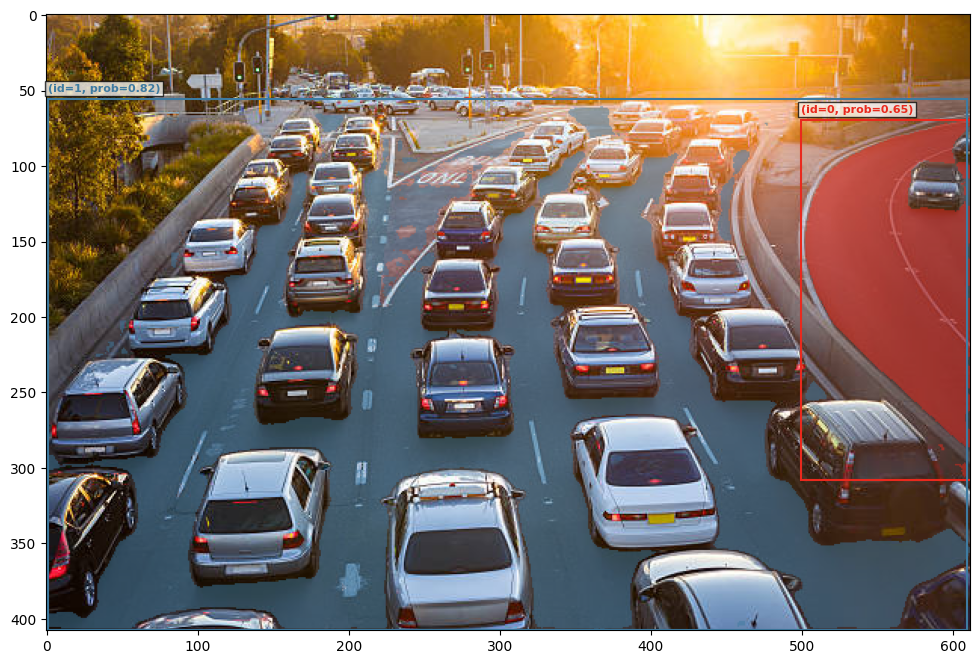

In [40]:
# Prompt the model with text
output = processor.set_text_prompt(state=inference_state, prompt="road")

# Get the masks, bounding boxes, and scores
masks, boxes, scores = output["masks"], output["boxes"], output["scores"]
plot_results(image, inference_state)